# 🐼 Pandas — Session

**Track:** Intro to Machine Learning — Data Analysis

Pandas is a Python library for working with **tabular data** (rows and columns).
- A **DataFrame** is a table.
- Each column in a DataFrame is a **Series** — think of it like a labeled, typed list.
- Pandas makes it easy to load, filter, clean, and analyze datasets — exactly the kind of
  work you do *before* feeding data into a machine learning model.

By the end of this session you will be able to:
- Create and load DataFrames
- Explore a new dataset systematically
- Handle missing data
- Subset rows/columns with slicing, boolean indexing, `loc`, and `iloc`
- Sort, aggregate, and `groupby`
- Use string methods and `apply`/`replace`
- Do a first pass of "feature engineering" — the bridge into ML

> This session reuses the house price dataset so every concept sticks to one real example.

In [74]:
# importing pandas
import pandas as pd
import numpy as np

## Series vs. DataFrame — a quick side-by-side

In [75]:
s = pd.Series([10, 20, 30], name="example_series")
print(type(s))
s

<class 'pandas.Series'>


0    10
1    20
2    30
Name: example_series, dtype: int64

If you want to create your own DataFrame, build a dictionary and pass it to `pd.DataFrame`:

In [76]:
new_data = {'name': ['ahmed', 'ali', 'mona'],
            'age': [20, 22, 19],
            'country': ['egypt', 'Iraq', 'Sudan']}
my_data = pd.DataFrame(new_data)
print(type(my_data))
my_data

<class 'pandas.DataFrame'>


,name,age,country
0,ahmed,20,egypt
1,ali,22,Iraq
2,mona,19,Sudan


In [77]:
# each column of a DataFrame IS a Series
print(type(my_data['age']))
my_data['age']

<class 'pandas.Series'>


0    20
1    22
2    19
Name: age, dtype: int64

## Reading and discovering data

We'll use a house price prediction dataset from Kaggle. In Colab you can pull it directly:

```python
pip install opendatasets
import opendatasets as od
od.download('https://www.kaggle.com/datasets/zafarali27/house-price-prediction-dataset')
```

This will prompt for a Kaggle username + API key on first run. Once downloaded, load it into a
DataFrame like below (adjust the path to wherever it landed on your machine — in Colab it's
usually under `/content/...`).

In [78]:
#import pandas as pd
data=pd.read_csv('https://raw.githubusercontent.com/Rajvardhan180/House_Price_Prediction/main/data/Housing.csv')
data.head()

#data = pd.read_csv("House Price Prediction Dataset.csv")
#data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


`.copy()` makes an independent copy — useful when you want to try something risky without touching the original `data`.

In [79]:
temp = data.copy()
temp.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [80]:
data.tail()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [81]:
data.shape

(545, 13)

In [82]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 69.2 KB


In [83]:
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

### Standardizing column names

Datasets from the wild are often inconsistent (mixed case, spaces, etc). It's good practice to
normalize column names right after loading, so you never have to remember whether it was `area`
or `Area`.

In [84]:
data.columns = data.columns.str.strip().str.lower()
data.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

## Exploring the data

In [85]:
data.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [86]:
data['area'].isnull().sum()

np.int64(0)

In [87]:
data.describe()  # numeric columns

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [88]:
data.describe(include='object')  # categorical (text) columns

C:\Users\Hp\AppData\Local\Temp\ipykernel_38064\2409392331.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')  # categorical (text) columns


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


In [89]:
data['area'].unique()

array([ 7420,  8960,  9960,  7500,  8580, 16200,  8100,  5750, 13200,
        6000,  6550,  3500,  7800,  6600,  8500,  4600,  6420,  4320,
        7155,  8050,  4560,  8800,  6540,  8875,  7950,  5500,  7475,
        7000,  4880,  5960,  6840,  7482,  9000,  6360,  6480,  4300,
        7440,  6325,  5150, 11440,  7680,  8880,  6240, 11175,  7700,
       12090,  4000,  5020,  4040,  4260,  6500,  5700, 10500,  3760,
        8250,  6670,  3960,  7410,  5000,  6750,  4800,  7200,  4100,
        6400,  6350,  4500,  5450,  3240,  6615,  8372,  9620,  6800,
        8000,  6900,  3700,  7020,  7231,  6254,  7320,  6525, 15600,
        7160, 11460,  5828,  5200,  5400,  4640,  5800,  6660,  4700,
        5136,  4400,  3300,  3650,  6100,  2817,  7980,  3150,  6210,
        6825,  6710,  6450, 10269,  8400,  5300,  3800,  9800,  8520,
        6050,  7085,  3180,  3410,  3000, 11410,  5720,  3540,  7600,
       10700,  8150,  4410,  7686,  2800,  5948,  4200,  4520,  4095,
        4120,  4770,

In [90]:
data['bedrooms'].unique()

array([4, 3, 5, 2, 6, 1])

In [91]:
data['bedrooms'] = data['bedrooms'].astype('int')
data.describe(include='object')

C:\Users\Hp\AppData\Local\Temp\ipykernel_38064\1917820660.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


Here we treated `bedrooms` as its true numeric type using `astype()` — pandas sometimes infers types incorrectly on load.

In [92]:
cat_cols = list(data.select_dtypes(include='object').columns)
cat_cols

C:\Users\Hp\AppData\Local\Temp\ipykernel_38064\2016449230.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(data.select_dtypes(include='object').columns)


['mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'prefarea',
 'furnishingstatus']

In [93]:
data.select_dtypes(include='int')  # show only columns of a specific dtype

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [94]:
data['furnishingstatus'].unique()

<ArrowStringArray>
['furnished', 'semi-furnished', 'unfurnished']
Length: 3, dtype: str

In [95]:
data['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [96]:
data.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

## Handling missing data

We checked `isnull().sum()` earlier — now let's actually do something about it. This step matters
a lot for ML: most models can't handle `NaN` values directly.

Two common strategies:
- **`dropna()`** — remove rows (or columns) with missing values
- **`fillna()`** — fill missing values with something sensible (mean, median, a constant, etc.)

In [97]:
# how many rows would we lose if we dropped every row with ANY missing value?
print("Original rows:", len(data))
print("Rows after dropna:", len(data.dropna()))

Original rows: 545
Rows after dropna: 545


In [98]:
# example: fill missing 'area' values with the column median instead of dropping rows
area_filled = data['area'].fillna(data['area'].median())
print("Missing before:", data['area'].isnull().sum())
print("Missing after :", area_filled.isnull().sum())

Missing before: 0
Missing after : 0


There's no universally correct choice — it depends on how much data is missing and why. In ML pipelines this decision is usually made explicit and documented.

## Subsetting columns

In [99]:
data['price']

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [100]:
data[['price', 'area', 'bedrooms']]

,price,area,bedrooms
0,13300000,7420,4
1,12250000,8960,4
2,12250000,9960,3
3,12215000,7500,4
4,11410000,7420,4
...,...,...,...
540,1820000,3000,2
541,1767150,2400,3
542,1750000,3620,2
543,1750000,2910,3


## Subsetting rows

### 1. Slicing

In [101]:
data[2:5]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### 2. Boolean indexing

In [102]:
data['area'] > 7000  # returns a boolean Series


0       True
1       True
2       True
3       True
4       True
       ...  
540    False
541    False
542    False
543    False
544    False
Name: area, Length: 545, dtype: bool

In [103]:
data[data['area'] > 7000]  # returns the sub-DataFrame where the condition is True

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
403,3500000,12944,3,1,1,yes,no,no,no,no,0,no,unfurnished
452,3150000,9000,3,1,2,yes,no,no,no,no,2,no,semi-furnished
460,3087000,8100,2,1,1,yes,no,no,no,no,1,no,unfurnished
473,3003000,8050,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [104]:
data[data['price'] > 150000]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [105]:
data[(data['price'] > 150000) & (data['mainroad'] == 'yes')]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [106]:
data[((data['area'] > 7000) & (data['bathrooms'] > 3)) | (data['furnishingstatus'] == 'furnished')]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,2590000,3600,2,2,2,yes,no,yes,no,no,1,no,furnished
512,2520000,3000,2,1,2,yes,no,no,no,no,0,no,furnished
522,2380000,2475,3,1,2,yes,no,no,no,no,0,no,furnished
523,2380000,2787,4,2,2,yes,no,no,no,no,0,no,furnished


## Accessing rows and columns using `loc` and `iloc`

**`.loc[]`** — label-based access. **`.iloc[]`** — position-based access. If your index is just
default integers 0,1,2..., they often look the same, but they're not — `loc` includes the end of a
slice range, `iloc` doesn't, and `loc` breaks if you re-index or filter the DataFrame (the labels
move with the rows, not the positions).

In [107]:
# data[1]  <-- this raises an error, plain [] doesn't do row-by-position access
data.loc[1]

price                12250000
area                     8960
bedrooms                    4
bathrooms                   4
stories                     4
mainroad                  yes
guestroom                  no
basement                   no
hotwaterheating            no
airconditioning           yes
parking                     3
prefarea                   no
furnishingstatus    furnished
Name: 1, dtype: object

In [108]:
data.loc[0, 'area']  # a single value: area of the row labeled 0

np.int64(7420)

In [109]:
data.loc[[0, 1, 3], ['price', 'bedrooms']]  # multiple rows and columns

,price,bedrooms
0,13300000,4
1,12250000,4
3,12215000,4


In [110]:
data[0:3][['price', 'bedrooms']]  # equivalent here, without loc

,price,bedrooms
0,13300000,4
1,12250000,4
2,12250000,3


In [111]:
data.iloc[5]  # access a single row by position

price                     10850000
area                          7500
bedrooms                         3
bathrooms                        3
stories                          1
mainroad                       yes
guestroom                       no
basement                       yes
hotwaterheating                 no
airconditioning                yes
parking                          2
prefarea                       yes
furnishingstatus    semi-furnished
Name: 5, dtype: object

In [112]:
data.iloc[0, 1]  # a single value by position

np.int64(7420)

In [113]:
data.iloc[1:3, 2:5]  # multiple rows and columns by position

,bedrooms,bathrooms,stories
1,4,4,4
2,3,2,2


## Sorting

`sort_values` is one of the most-used pandas methods — for finding top/bottom records, or just
making a table readable.

In [114]:
data.sort_values('price', ascending=False).head()  # most expensive houses first

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [115]:
data.sort_values(['furnishingstatus', 'price'], ascending=[True, False]).head()  # sort by multiple columns

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished


## Aggregation

In [116]:
avg_price = data['price'].mean()
avg_price

np.float64(4766729.247706422)

In [117]:
max_price = data['price'].max()  # avoid naming this 'max' — it shadows the Python builtin!
max_price

np.int64(13300000)

In [118]:
data[['mainroad', 'guestroom']].mode()

,mainroad,guestroom
0,yes,no


In [119]:
(data['bedrooms'] < 2).sum()  # counting how many rows satisfy a condition

np.int64(2)

**`agg()`**: used when you want to apply multiple functions, or a different function per column, in one call.

In [120]:
data['price'].agg('mean')

np.float64(4766729.247706422)

In [121]:
data['area'].agg(['mean', 'min', 'max'])

mean     5150.541284
min      1650.000000
max     16200.000000
Name: area, dtype: float64

In [122]:
data.agg({'price': 'median', 'area': 'mean'})

price    4.340000e+06
area     5.150541e+03
dtype: float64

## Group by

**Without `groupby`** — doable, but repetitive and doesn't scale past a couple of categories:

In [123]:
f1 = data[data['furnishingstatus'] == 'furnished']['price'].max()
f2 = data[data['furnishingstatus'] == 'semi-furnished']['price'].max()
f3 = data[data['furnishingstatus'] == 'unfurnished']['price'].max()
print(f1, f2, f3)

13300000 12250000 10150000


**With `groupby`** — same idea, one line, and it scales to any number of categories:

In [124]:
data.groupby('furnishingstatus')['price'].max()

furnishingstatus
furnished         13300000
semi-furnished    12250000
unfurnished       10150000
Name: price, dtype: int64

In [125]:
data.groupby('furnishingstatus')['price'].agg(['min', 'max'])

,min,max
furnishingstatus,,
furnished,1750000,13300000
semi-furnished,1767150,12250000
unfurnished,1750000,10150000


In [126]:
data.groupby(['furnishingstatus', 'airconditioning'])['price'].mean()

furnishingstatus  airconditioning
furnished         no                 4.469500e+06
                  yes                6.786717e+06
semi-furnished    no                 4.557951e+06
                  yes                5.778769e+06
unfurnished       no                 3.583342e+06
                  yes                5.286167e+06
Name: price, dtype: float64

### `pivot_table` — groupby's spreadsheet-style cousin

`pivot_table` is handy when you want categories laid out as rows *and* columns at once
(like an Excel pivot table).

In [127]:
data.pivot_table(values='price', index='furnishingstatus', columns='airconditioning', aggfunc='mean')

airconditioning,no,yes
furnishingstatus,,
furnished,4.469500e+06,6.786717e+06
semi-furnished,4.557951e+06,5.778769e+06
unfurnished,3.583342e+06,5.286167e+06


## Common string functions

String methods live under `.str` on a Series of text.

In [128]:
data['furnishingstatus'] = data['furnishingstatus'].str.upper()
data['furnishingstatus'].head()

0         FURNISHED
1         FURNISHED
2    SEMI-FURNISHED
3         FURNISHED
4         FURNISHED
Name: furnishingstatus, dtype: str

In [129]:
data['furnishingstatus'] = data['furnishingstatus'].str.lower()
data['furnishingstatus'].head()

0         furnished
1         furnished
2    semi-furnished
3         furnished
4         furnished
Name: furnishingstatus, dtype: str

⚠️ A subtle regex trap: `'semi | SEMI'` (with spaces around the `|`) matches the literal
strings `'semi '` or `' SEMI'` — **including the space** — not just `semi`/`SEMI` case-insensitively.
The fix: drop the spaces, and use `case=False` for case-insensitive matching instead of listing
both cases yourself.

In [130]:
# buggy version (kept here on purpose, to see the difference)
buggy = data[data['furnishingstatus'].str.contains('semi | SEMI')]
print("buggy match count:", len(buggy))

# correct version
fixed = data[data['furnishingstatus'].str.contains('semi', case=False)]
print("fixed match count:", len(fixed))

buggy match count: 0
fixed match count: 227


## Some other useful functions

In [131]:
data['guestroom'].unique()

<ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str

In [132]:
yes_no = {'yes': 1, 'no': 0}
data['guestroom'] = data['guestroom'].replace(yes_no)
data['guestroom'].head()

0    0
1    0
2    0
3    0
4    1
Name: guestroom, dtype: object

👀 **This is your first taste of feature engineering.** Machine learning models need numbers,
not the text `'yes'`/`'no'`. Turning categories into 0/1 like this is exactly what you'll do
(in a more automated way, e.g. `pd.get_dummies` or `LabelEncoder`) before training a model.

In [133]:
data['area'].apply(lambda x: x / 100)  # apply() runs a function on every value in the Series

0      74.2
1      89.6
2      99.6
3      75.0
4      74.2
       ... 
540    30.0
541    24.0
542    36.2
543    29.1
544    38.5
Name: area, Length: 545, dtype: float64

In [134]:
# store the result in a NEW column instead of overwriting 'bathrooms'
data['bathrooms_label'] = data['bathrooms'].where(data['bathrooms'] > 2, 'less than 2')
data[['bathrooms', 'bathrooms_label']].head()

,bathrooms,bathrooms_label
0,2,less than 2
1,4,4
2,2,less than 2
3,2,less than 2
4,1,less than 2


⚠️ Careful: `.where()` here produces a column mixing numbers and the string `'less than 2'` —
that's a mixed-type `object` column. That's fine for a quick display label, but you'd want to
avoid doing this to a column you plan to feed into a model — keep numeric columns numeric, and
put any such label in a **separate** column (like we just did) instead of overwriting the original.
Overwriting `bathrooms` itself, as the original version of this notebook did, would silently break
any later numeric calculation on that column.

## A first look with visualization

Pandas has basic plotting built in (via matplotlib under the hood). A quick chart often reveals
things `describe()` won't — like skew, outliers, or an unexpected concentration of values.

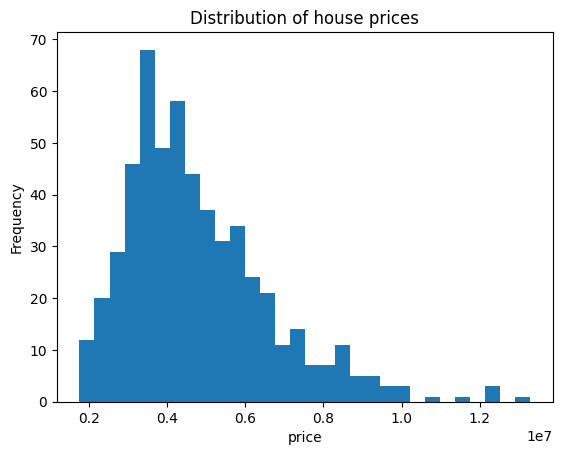

In [135]:
import matplotlib.pyplot as plt

data['price'].plot(kind='hist', bins=30, title='Distribution of house prices')
plt.xlabel('price')
plt.show()

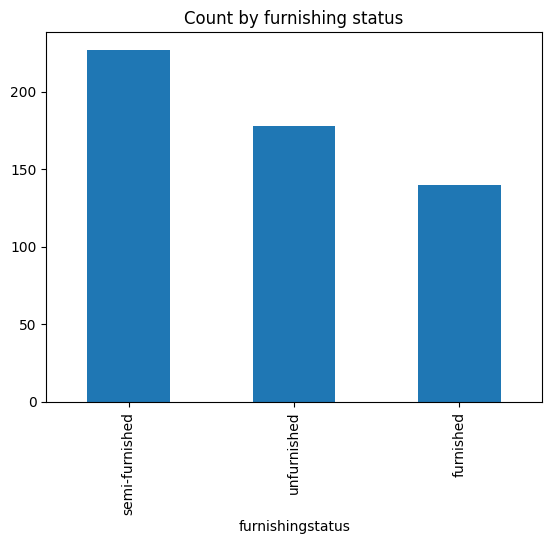

In [136]:
data['furnishingstatus'].value_counts().plot(kind='bar', title='Count by furnishing status')
plt.show()

We'll go much deeper into visualization in a future session — for now, know that `.plot()` exists and is often your fastest sanity check on a dataset.

In [137]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,bathrooms_label
0,13300000,7420,4,2,3,yes,0,no,no,yes,2,yes,furnished,less than 2
1,12250000,8960,4,4,4,yes,0,no,no,yes,3,no,furnished,4
2,12250000,9960,3,2,2,yes,0,yes,no,no,2,yes,semi-furnished,less than 2
3,12215000,7500,4,2,2,yes,0,yes,no,yes,3,yes,furnished,less than 2
4,11410000,7420,4,1,2,yes,1,yes,no,yes,2,no,furnished,less than 2


---

## 📝 Exercise 1

- Filter the dataset to include only **premium properties**: has a guestroom, `area` greater than 3000, and has air conditioning.
- Then group the filtered data by `furnishingstatus` and compute:
  - the average price
  - the average number of bedrooms
  - the count of such premium properties in each furnishing category

Try it yourself first.

In [138]:
# Your code here

premium= data[(data['guestroom']==1) & (data['area']>3000) & (data['airconditioning']=='yes')    ]

print(premium.groupby('furnishingstatus')['price'].mean())
print(premium.groupby('furnishingstatus')['bedrooms'].mean())
print(premium.groupby('furnishingstatus').count())


furnishingstatus
furnished         7.039455e+06
semi-furnished    6.170231e+06
unfurnished       7.185938e+06
Name: price, dtype: float64
furnishingstatus
furnished         3.545455
semi-furnished    3.000000
unfurnished       3.125000
Name: bedrooms, dtype: float64
                  price  area  bedrooms  bathrooms  stories  mainroad  \
furnishingstatus                                                        
furnished            22    22        22         22       22        22   
semi-furnished       13    13        13         13       13        13   
unfurnished           8     8         8          8        8         8   

                  guestroom  basement  hotwaterheating  airconditioning  \
furnishingstatus                                                          
furnished                22        22               22               22   
semi-furnished           13        13               13               13   
unfurnished               8         8                8             

<details>
<summary>💡 Click to see one possible solution</summary>

```python
premium = data[(data['guestroom'] == 1) &
               (data['area'] > 3000) &
               (data['airconditioning'] == 'yes')]

premium.groupby('furnishingstatus').agg(
    avg_price=('price', 'mean'),
    avg_bedrooms=('bedrooms', 'mean'),
    count=('price', 'size')
)
```
</details>

In [ ]:
# Solution
premium = data[(data['guestroom'] == 1) &
               (data['area'] > 3000) &
               (data['airconditioning'] == 'yes')]

premium.groupby('furnishingstatus').agg(
    avg_price=('price', 'mean'),
    avg_bedrooms=('bedrooms', 'mean'),
    count=('price', 'size')
)

,avg_price,avg_bedrooms,count
furnishingstatus,,,
furnished,7.039455e+06,3.545455,22
semi-furnished,6.170231e+06,3.000000,13
unfurnished,7.185938e+06,3.125000,8


## 📝 Exercise 2

- Create a new column called `energy_load`, calculated as:
  `energy_load = (area * 0.5) + (bedrooms * 100) + (bathrooms * 150)`
- Filter the data to include only houses that:
  1. Have `airconditioning == 'yes'`
  2. Have `hotwaterheating == 'yes'`
- Group the filtered data by `furnishingstatus` and compute:
  1. Average `energy_load`
  2. Average `price`

In [156]:
# Your code here

data['energy_load']= (data['area']*0.5) + (data['bedrooms']*100) + (data['bathrooms']*150)

sub = data[(data['airconditioning'] == 'yes') & (data['hotwaterheating'] == 'yes')]

print(sub.groupby('furnishingstatus')['energy_load'].mean())
print(sub.groupby('furnishingstatus')['price'].mean())


furnishingstatus
semi-furnished    1587.5
Name: energy_load, dtype: float64
furnishingstatus
semi-furnished    3640000.0
Name: price, dtype: float64


In [141]:
# Solution
data['energy_load'] = (data['area'] * 0.5) + (data['bedrooms'] * 100) + (data['bathrooms'] * 150)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,bathrooms_label,energy_load
0,13300000,7420,4,2,3,yes,0,no,no,yes,2,yes,furnished,less than 2,4410.0
1,12250000,8960,4,4,4,yes,0,no,no,yes,3,no,furnished,4,5480.0
2,12250000,9960,3,2,2,yes,0,yes,no,no,2,yes,semi-furnished,less than 2,5580.0
3,12215000,7500,4,2,2,yes,0,yes,no,yes,3,yes,furnished,less than 2,4450.0
4,11410000,7420,4,1,2,yes,1,yes,no,yes,2,no,furnished,less than 2,4260.0


In [142]:
sub = data[(data['airconditioning'] == 'yes') & (data['hotwaterheating'] == 'yes')]
sub.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,bathrooms_label,energy_load
378,3640000,2275,3,1,3,yes,0,no,yes,yes,0,yes,semi-furnished,less than 2,1587.5


In [143]:
sub.groupby('furnishingstatus').agg({'price': 'mean', 'energy_load': 'mean'})

,price,energy_load
furnishingstatus,,
semi-furnished,3640000.0,1587.5


## ✅ Cheat sheet

| Task | Function |
|---|---|
| Create/load | `pd.DataFrame`, `pd.read_csv` |
| Explore | `.head/.tail/.shape/.info/.describe/.dtypes/.nunique/.value_counts` |
| Missing data | `.isnull().sum()`, `.dropna()`, `.fillna()` |
| Select columns | `df['col']`, `df[['col1','col2']]` |
| Select rows | slicing, boolean masks, `.loc`, `.iloc` |
| Sort | `.sort_values()` |
| Aggregate | `.mean/.max/.min/.agg()` |
| Group | `.groupby()`, `.pivot_table()` |
| Text | `.str.upper/.lower/.contains(case=False)` |
| Transform | `.apply()`, `.replace()`, `.where()`, `.astype()` |
| Quick viz | `.plot(kind=...)` |

## 🔗 Where this goes next

Today's `guestroom` yes/no → 1/0 conversion is a preview of **feature engineering** — turning raw
columns into a numeric table a model can learn from. Next steps in the ML track will build directly
on this: encoding categorical variables properly, scaling numeric features, and splitting data
into train/test sets — all still using pandas + numpy underneath.